In [1]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report ,confusion_matrix, accuracy_score
import optuna

1. Veriyi Yükleme işlemi

In [2]:

df = pd.read_csv('missense_mutations.csv')

Belirsiz (-1) sınıfların çıkartılması

In [3]:
df_filtered = df[df['ClinSigSimple'].isin([0, 1])].copy()

Özelliklerin belirlenmesi ve gereksi sütunların çıkartılması

In [4]:
features = ['GeneSymbol', 'Chromosome', 'Start', 'Stop', 
            'ReferenceAlleleVCF', 'AlternateAlleleVCF', 'NumberSubmitters']
X = df_filtered[features]
y = df_filtered['ClinSigSimple']

Kategorik değişkenlerin dönüştürülmesi işlemi

In [5]:
cat_cols = ['GeneSymbol', 'ReferenceAlleleVCF', 'AlternateAlleleVCF']
for col in cat_cols:
    X[col] = X[col].astype('category')

C:\Users\emirh\AppData\Local\Temp\ipykernel_6724\1920476134.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype('category')
C:\Users\emirh\AppData\Local\Temp\ipykernel_6724\1920476134.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].astype('category')
C:\Users\emirh\AppData\Local\Temp\ipykernel_6724\1920476134.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See

In [6]:
X

,GeneSymbol,Chromosome,Start,Stop,ReferenceAlleleVCF,AlternateAlleleVCF,NumberSubmitters
0,BRCA2,13,32906729,32906729,A,C,39
1,BRCA2,13,32332592,32332592,A,C,39
2,BRCA2,13,32937504,32937504,C,G,22
3,BRCA2,13,32363367,32363367,C,G,22
4,BRCA2,13,32930658,32930658,T,C,11
...,...,...,...,...,...,...,...
11229,BRCA2,13,32376791,32376791,G,C,1
11230,BRCA2,13,32906922,32906922,A,G,1
11231,BRCA2,13,32332785,32332785,A,G,1
11232,BRCA1,17,41256888,41256888,C,G,1


Veri setinin eğitim/test şeklinde parçalanması

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Modelin Eğitimi 

In [8]:
params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'is_unbalance': True,  # Sınıf dengesizliğini otomatik yönetir
    'learning_rate': 0.05,
    'verbose': -1
}

train_data = lgb.Dataset(X_train, label=y_train)
model = lgb.train(params, train_data, num_boost_round=100)

Sonuç

In [9]:
y_pred = (model.predict(X_test) >= 0.5).astype(int)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.82      0.89      1637
           1       0.31      0.79      0.44       166

    accuracy                           0.82      1803
   macro avg       0.64      0.80      0.67      1803
weighted avg       0.91      0.82      0.85      1803



In [10]:
cm = confusion_matrix(y_test, y_pred)

In [11]:
cm

array([[1342,  295],
       [  35,  131]], dtype=int64)

In [12]:
acc = accuracy_score(y_test, y_pred)
acc

0.8169717138103162

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

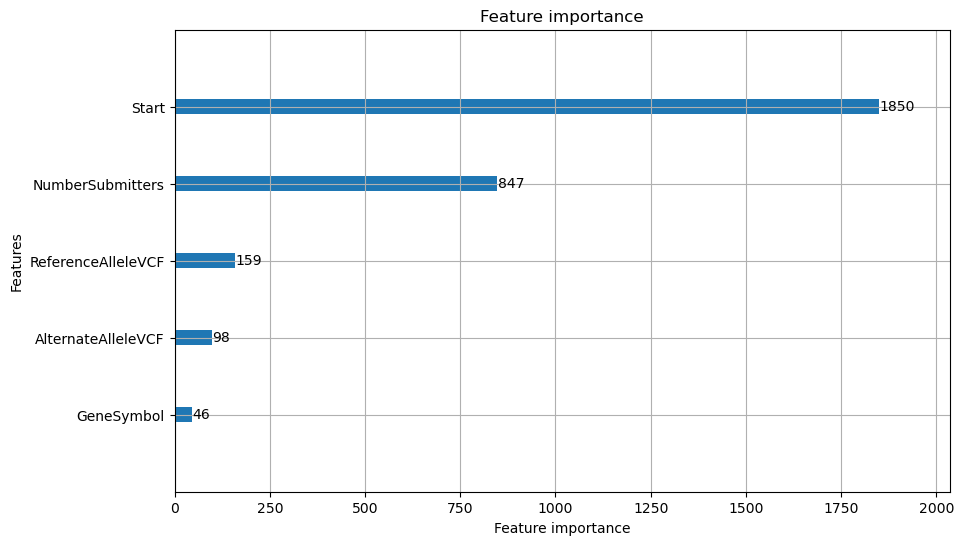

In [13]:
lgb.plot_importance(model, importance_type='split', figsize=(10, 6))

## Optuna Kullanılması

In [14]:
def objective(trial):
    # 1. Parametre
    param = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'num_leaves': trial.suggest_int('num_leaves', 2, 256),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
    }

    # 2. Model
    model = lgb.LGBMClassifier(**param)

    # 3. Eğitim
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=0)]
    )

    # 4. Skor
    preds = model.predict(X_test)
    accuracy = accuracy_score(y_test, preds)
    return accuracy

In [15]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

[I 2026-03-22 18:15:30,451] A new study created in memory with name: no-name-ca29605a-18ef-453a-8f63-1befedcbb71e


Training until validation scores don't improve for 50 rounds


[I 2026-03-22 18:15:30,915] Trial 0 finished with value: 0.9173599556295063 and parameters: {'num_leaves': 148, 'max_depth': 11, 'learning_rate': 0.018997568517655508, 'n_estimators': 222, 'min_child_samples': 28, 'feature_fraction': 0.5242091689971811, 'bagging_fraction': 0.5017835671367449, 'bagging_freq': 3}. Best is trial 0 with value: 0.9173599556295063.


Did not meet early stopping. Best iteration is:
[192]	valid_0's binary_logloss: 0.204505
Training until validation scores don't improve for 50 rounds


[I 2026-03-22 18:15:31,514] Trial 1 finished with value: 0.9079312257348863 and parameters: {'num_leaves': 79, 'max_depth': 7, 'learning_rate': 0.0014507542906866905, 'n_estimators': 621, 'min_child_samples': 66, 'feature_fraction': 0.9467088585007007, 'bagging_fraction': 0.7278106403394828, 'bagging_freq': 2}. Best is trial 0 with value: 0.9173599556295063.


...

[I 2026-03-22 18:15:47,084] Trial 47 finished with value: 0.9179145867997781 and parameters: {'num_leaves': 219, 'max_depth': 4, 'learning_rate': 0.05570131420634488, 'n_estimators': 437, 'min_child_samples': 5, 'feature_fraction': 0.40719535834791426, 'bagging_fraction': 0.9254062020090543, 'bagging_freq': 1}. Best is trial 36 with value: 0.920687742651137.


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[183]	valid_0's binary_logloss: 0.205293
Training until validation scores don't improve for 50 rounds


[I 2026-03-22 18:15:47,249] Trial 48 finished with value: 0.9179145867997781 and parameters: {'num_leaves': 173, 'max_depth': 5, 'learning_rate': 0.06288200029041453, 'n_estimators': 484, 'min_child_samples': 12, 'feature_fraction': 0.43196044050835447, 'bagging_fraction': 0.8305392241096874, 'bagging_freq': 2}. Best is trial 36 with value: 0.920687742651137.


Early stopping, best iteration is:
[135]	valid_0's binary_logloss: 0.20127
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[95]	valid_0's binary_logloss: 0.20462


[I 2026-03-22 18:15:47,432] Trial 49 finished with value: 0.9179145867997781 and parameters: {'num_leaves': 142, 'max_depth': 6, 'learning_rate': 0.08074263940901141, 'n_estimators': 373, 'min_child_samples': 10, 'feature_fraction': 0.5265525872781155, 'bagging_fraction': 0.8921575260033423, 'bagging_freq': 2}. Best is trial 36 with value: 0.920687742651137.


In [16]:
print(f"0.2 Validasyon ile En İyi Skor: {study.best_value}")
print(f"En İyi Parametreler: {study.best_params}")

0.2 Validasyon ile En İyi Skor: 0.920687742651137
En İyi Parametreler: {'num_leaves': 169, 'max_depth': 7, 'learning_rate': 0.05483703332519742, 'n_estimators': 996, 'min_child_samples': 28, 'feature_fraction': 0.47843723421793427, 'bagging_fraction': 0.8117435071142622, 'bagging_freq': 4}


## Threshold Değerinini Değiştirilmesi

Modele değerin 0.5 ten 0.45 e çekilerek başarımdaki farklılık değerlendirilecektir

In [17]:
y_pred2 = (model.predict(X_test) >= 0.45).astype(int)
print(classification_report(y_test, y_pred2))

              precision    recall  f1-score   support

           0       0.98      0.79      0.88      1637
           1       0.29      0.81      0.42       166

    accuracy                           0.80      1803
   macro avg       0.63      0.80      0.65      1803
weighted avg       0.91      0.80      0.83      1803



In [18]:
cm2 = confusion_matrix(y_test, y_pred2)
cm2

array([[1300,  337],
       [  31,  135]], dtype=int64)

In [19]:
acc2 = accuracy_score(y_test, y_pred2)
acc2

0.7958957293399889